ベータ分布

In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
from IPython.display import display
import seaborn as sns
np.set_printoptions(precision=3, floatmode='fixed')
plt.rcParams["font.size"] = 14
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["axes.grid"] = True
pd.options.display.float_format = "{:.3f}".format
pd.set_option("display.max_columns", None)

import pymc as pm
import arviz as az

print(f"Running on PyMC v{pm.__version__}")
print(f"Running on ArviZ v{az.__version__}")

Running on PyMC v5.27.0
Running on ArviZ v0.23.0


くじにあたった回数２回，はずれた回数３回のときの確率pの確からしさ(尤度)

Text(0, 0.5, '尤度')

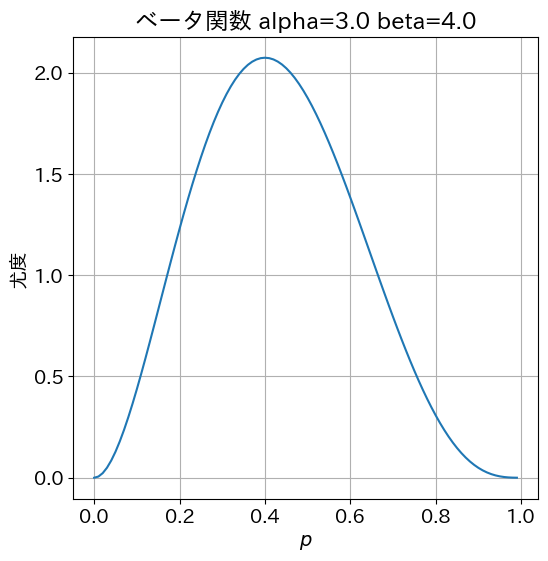

In [3]:
from math import gamma # 階上を計算する

alpha = 2.0 + 1.0
beta = 3.0 + 1.0

def Beta(p, alpha, beta):
    C = gamma(alpha+beta-1)/(gamma(alpha-1)*gamma(beta-1))
    return C * p ** (alpha-1) * (1-p) ** (beta-1)

# x座標
# 0.0 < p < 1.0
p = np.arange(0.0, 1.0, 0.01)

plt.plot(p, Beta(p, alpha, beta))
plt.title(f"ベータ関数 alpha={alpha} beta={beta}")
plt.xlabel(r"$p$")
plt.ylabel("尤度")

In [5]:
alpha = 2.0 + 1.0
beta = 3.0 + 1.0

model8 = pm.Model()
with model8:
    # pm.Beta: ベータ分布
    # alpha: くじに当たった回数 + 1
    # beta: くじに外れた回数 + 1
    p = pm.Beta('p', alpha=alpha, beta=beta)

with model8:
    prior_samples8 = pm.sample_prior_predictive(random_seed=42)

p_samples8 = prior_samples8['prior']['p'].values
print(p_samples8[:,:100])

Sampling: [p]


[[0.478 0.778 0.745 0.639 0.689 0.182 0.314 0.431 0.472 0.491 0.764 0.209
  0.659 0.398 0.361 0.357 0.478 0.359 0.413 0.690 0.768 0.479 0.237 0.154
  0.286 0.583 0.231 0.492 0.248 0.549 0.377 0.435 0.635 0.457 0.690 0.563
  0.237 0.724 0.540 0.141 0.489 0.594 0.480 0.218 0.316 0.736 0.246 0.087
  0.447 0.532 0.362 0.203 0.189 0.300 0.219 0.576 0.309 0.381 0.670 0.196
  0.284 0.351 0.386 0.691 0.549 0.536 0.440 0.412 0.501 0.808 0.528 0.360
  0.485 0.374 0.588 0.266 0.662 0.469 0.620 0.299 0.840 0.284 0.672 0.734
  0.324 0.326 0.516 0.221 0.721 0.675 0.265 0.177 0.445 0.313 0.302 0.199
  0.483 0.575 0.528 0.389]]


In [6]:
value_counts8 = pd.DataFrame(p_samples8.reshape(-1)).value_counts().sort_index()
print(value_counts8)

0    
0.013    1
0.062    1
0.067    1
0.082    1
0.083    1
        ..
0.808    1
0.814    1
0.837    1
0.840    1
0.844    1
Name: count, Length: 500, dtype: int64


In [7]:
# サンプリング結果の分析
summary8 = az.summary(prior_samples8, kind='stats')
display(summary8)

,mean,sd,hdi_3%,hdi_97%
p,0.433,0.181,0.120,0.760


Text(0.5, 1.0, 'ベータ分布 alpha=3.0 beta=4.0')

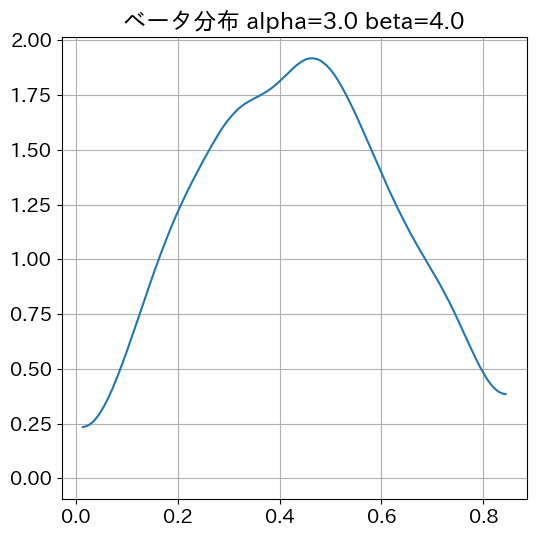

In [8]:
ax = az.plot_dist(p_samples8)
ax.set_title(f"ベータ分布 alpha={alpha} beta={beta}")

Text(0.5, 1.0, 'ベータ分布 alpha=3.0 beta=4.0')

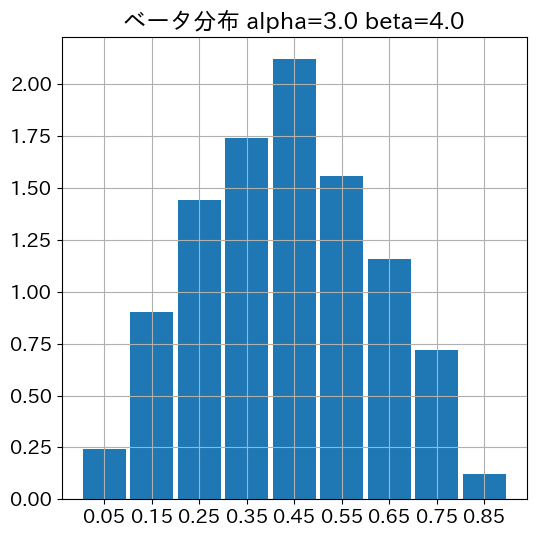

In [9]:
bins = np.arange(0, 1.0, 0.1)
ax = az.plot_dist(p_samples8, kind='hist', hist_kwargs={"bins":bins})
ax.set_title(f"ベータ分布 alpha={alpha} beta={beta}")

alpha=21, beta=31
くじを50回ひいいて，20回あたりのときの確率ｐの確からしさ

In [10]:
alpha = 20.0 + 1.0
beta = 30.0 + 1.0

model9 = pm.Model()
with model9:
    p = pm.Beta('p', alpha=alpha, beta=beta)
    prior_samples9 = pm.sample_prior_predictive(random_seed=42)

p_samples9 = prior_samples9['prior']['p'].values
print(p_samples9[:,:100])

Sampling: [p]


[[0.423 0.540 0.509 0.482 0.510 0.310 0.363 0.403 0.420 0.432 0.535 0.324
  0.474 0.396 0.381 0.379 0.421 0.381 0.398 0.491 0.533 0.423 0.341 0.287
  0.351 0.461 0.329 0.422 0.344 0.452 0.387 0.408 0.476 0.415 0.495 0.454
  0.336 0.523 0.446 0.281 0.428 0.456 0.424 0.586 0.494 0.371 0.380 0.493
  0.458 0.428 0.412 0.369 0.567 0.509 0.453 0.324 0.472 0.396 0.354 0.427
  0.526 0.432 0.429 0.336 0.380 0.355 0.413 0.365 0.273 0.421 0.317 0.348
  0.422 0.469 0.386 0.338 0.484 0.315 0.354 0.396 0.411 0.242 0.428 0.345
  0.387 0.339 0.445 0.424 0.328 0.295 0.425 0.519 0.465 0.323 0.463 0.476
  0.457 0.368 0.298 0.413]]


In [11]:
value_counts9 = pd.DataFrame(p_samples9.reshape(-1)).value_counts().sort_index()
print(value_counts9)

0    
0.174    1
0.225    1
0.242    1
0.249    1
0.251    1
        ..
0.571    1
0.578    1
0.585    1
0.586    1
0.598    1
Name: count, Length: 500, dtype: int64


In [12]:
# サンプリング結果の分析
summary9 = az.summary(prior_samples9, kind='stats')
display(summary9)

,mean,sd,hdi_3%,hdi_97%
p,0.403,0.068,0.281,0.534


Text(0.5, 1.0, 'ベータ分布 alpha=21.0 beta=31.0')

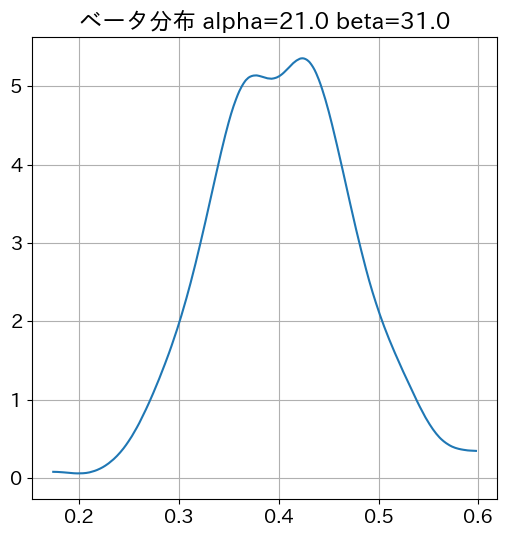

In [13]:
ax = az.plot_dist(p_samples9)
ax.set_title(f"ベータ分布 alpha={alpha} beta={beta}")